## Imports

In [ ]:
# importing sys
import sys
# This is how you import modules that exist outside of working directory 
# adding mosaique to the system path
sys.path.insert(1, '/workspaces/QML-QPF/mosaiQue') 

import mosaique as mq
import scipy
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras

## Check GPU installation is working

In [ ]:
import tensorflow as tf 
import tensorrt as trt

print(f' tensorflow version {tf.__version__}')

print(f' tensorrt version {trt.__version__}')

print(tf.config.list_physical_devices('GPU'))

In [3]:

# Set the environment for asynchronous GPU usage
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [2]:
def operation():
    dev = qml.device("default.qubit.tf", wires=4)
    @qml.qnode(dev, interface='tf')
    def cnot(inputs):
        inputs = inputs * np.pi
        qml.AngleEmbedding(inputs[:,...], wires=range(4), rotation='Y')

        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])

        # Measurement producing 4 classical output values
        return [qml.expval(qml.PauliZ(j)) for j in range(4)]
    return cnot


In [ ]:
def preset():
     # load the data tf.keras.datasets.fashion_mnist.load_data()

    fashion_mnist_dataset = keras.datasets.fashion_mnist
    (tr_images, tr_labels), (te_images, te_labels) = fashion_mnist_dataset.load_data()
    
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4("results_FashionMnist_train")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4("results_FashionMnist_test")
    
    #if you want slice the data for check reasons
    # tr_images = tr_images[:50:]
    # tr_labels = tr_labels[:50]
    # te_images = te_images[:10:]
    # te_labels = te_labels[:10]
    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_layer, (tr_images, tr_labels)), (te_layer,(te_images, te_labels)))

with ProcessPoolExecutor() as executor:
    future = executor.submit(preset)

((train_layer, (train_images, train_labels)), (test_layer,(test_images, test_labels))) = future.result() #This blocks until the task completes

In [5]:

permutations = np.asarray(list(itertools.permutations(range(4))))

def pool(x, call, p, l):
    op = OperationLayer(call())
    predict = l.post_transform(op.pre_op.predict(x,batch_size=1000))
    l.save(predict, p)

In [ ]:
# # not using PorcessPoolExecutor

# for p in permutations:
#     pool(train_images[:,:,p],)

In [ ]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=train_images[:,:,p], call=operation, p=p, l=train_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

In [ ]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=test_images[:,:,p], call=operation, p=p, l=test_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

In [ ]:
from keras.callbacks import CSVLogger

def run(tr_images, te_images, label):
    # change the subfolder name to save your data in different location based on what NN model you used
    # it's a convenient way to avoid losing your training data of each model
    # Here are some preset examples you can use
    # 1 FC layer
    run_subfolder = "_1FC"
    # # 2 FC layer
    # run_subfolder = "_2FC"
    # # 3 FC layer
    # run_subfolder = "_3FC"
    log_dir = train_layer.name + "/run" + run_subfolder +  "/"
    log_file =  log_dir + label
    os.makedirs(log_dir, exist_ok=True)
    
    csv_logger = CSVLogger(log_file)
    
    # tensorboard_callback = keras.callbacks.TensorBoard(
    #     log_dir=log_file,
    #     histogram_freq=1,
    #     write_graph=True,
    #     write_images=True,
    #     write_steps_per_second=True,
    #     update_freq='batch',
    #     profile_batch=1,
    #     embeddings_freq=1,
    #     embeddings_metadata=None
    # )
    
    number_of_classes = len(np.unique(test_labels))
    # Chose which model you want to use depending on the number of hidden layers
    # Uncomment the your model and run the code--pay attention to your folder/file naming to keep everything organized 
    ####---------------------------------------------------------------------####
    
    # simple ANN model with 0 hidden layers: 1FC
    q_model = keras.models.Sequential([
        keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
        keras.layers.Flatten(),
        keras.layers.Dense(number_of_classes, activation="softmax")
    ])
    
    ####---------------------------------------------------------------------####
    
    # # simple ANN model with 1 hidden layers: 2FC
    # q_model = keras.models.Sequential([
    #     keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
    #     keras.layers.Flatten(),
    #     keras.layers.Dense(250, activation='relu'),
    #     keras.layers.Dense(number_of_classes, activation="softmax")
    # ])
    
    ####---------------------------------------------------------------------####
    
    # simple ANN model with 2 hidden layers: 3FC
    # q_model = keras.models.Sequential([
    #     keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
    #     keras.layers.Flatten(),
    #     keras.layers.Dense(500, activation='relu'),
    #     keras.layers.Dense(250, activation='relu'),
    #     keras.layers.Dense(number_of_classes, activation='sigmoid')
    # ])
    
    ####---------------------------------------------------------------------####
    
    q_model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    q_history = q_model.fit(
        tr_images,
        train_labels,
        validation_data=(te_images, test_labels),
        batch_size=128,
        epochs=60,
        verbose=2,
        # callbacks=[tensorboard_callback]
        callbacks = csv_logger
    )

def model(variant, tr_layer, te_layer):
    tr_images = tr_layer.open(variant)
    te_images =  te_layer.open(variant)

    label = ''.join(map(str,variant))

    run(tr_images, te_images, label)

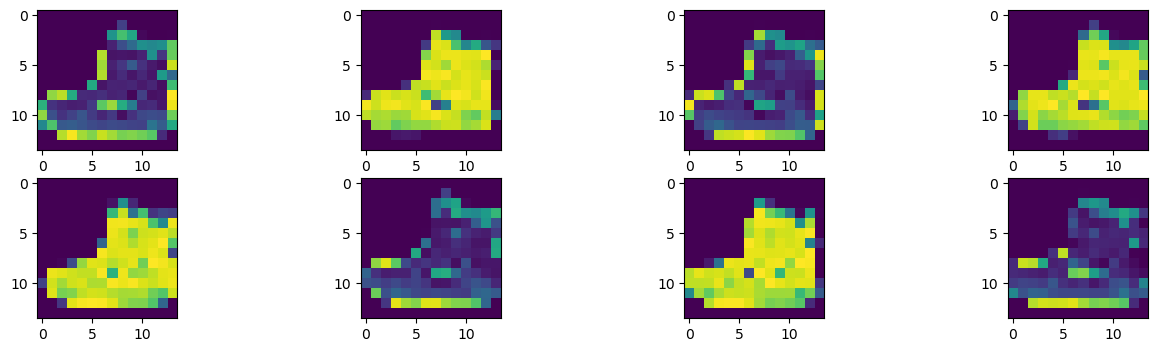

In [7]:
from matplotlib import pyplot as plt

# print(test_layer.open([0,1,3,2]).shape)

# post = test_layer.open([0,1,3,2])

# _min, _max = np.amin(post), np.amax(post)
# fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# # Plot all output channels for quantum cnot
# for c in range(4):
#     axes[c].imshow(post[0,:,:,c],vmin = _min, vmax = _max)
    
post = train_layer.open([1,2,3,0])
post1 = train_layer.open([2,3,0,1])


_min, _max = np.amin(post), np.amax(post)
_min1, _max1 = np.amin(post1), np.amax(post1)
fig, axes = plt.subplots(2, 4, figsize=(16, 4))

# Plot all output channels for quantum cnot
for c in range(4):
    axes[0,c].imshow(post[0,:,:,c],vmin = _min, vmax = _max)
    axes[1,c].imshow(post1[0,:,:,c],vmin = _min1, vmax = _max1)

In [ ]:

for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(model,variant = p, tr_layer = train_layer, te_layer= test_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

In [ ]:
# for ind, variant  in enumerate(permutations):

#     label = ''.join(map(str,variant))
#     print(ind, label)
#     tr_images = train_layer.open(variant)
#     te_images =  test_layer.open(variant)
#     run(tr_images,te_images,label)

In [ ]:
# run the network without filter

run(train_images,test_images,"NO-FILTER")

# Read Validation accuracy 
Now we will read from the csv and group the experiment validation for the last 30 epoch into the symmetries

In [10]:
# group the index of the permutation by the symmetry of the filter

diagonal_index = [4, 5, 8, 9, 14, 15, 18, 19]
vertical_index = [0, 1, 6, 7, 16, 17, 22, 23]
horizontal_index = [2, 3, 10, 11, 12, 13, 20, 21]

In [ ]:
import pandas as pd

diagonal_val_accuracy = []
vertical_val_accuracy = []
horizontal_val_accuracy = []

for ind, variant  in enumerate(permutations):
    label = ''.join(map(str,variant))
    # print(label)
    # file = train_layer.name + "/run/" + label
    # print(file)
    # Here are some preset examples you can use depending on which model you used to train your data 
    # 1 FC layer
    run_subfolder = "_1FC"
    # # 2 FC layer
    # run_subfolder = "_2FC"
    # # 3 FC layer
    # run_subfolder = "_3FC"
    file = train_layer.name + "/run" + run_subfolder +  "/" + label
    #read the csv file
    df = pd.read_csv(file)
    
    # the number of last validation accuracy
    tail_accuracy = 30
    
    if ind in diagonal_index:
        diagonal_val_accuracy.append(df['val_accuracy'].tail(tail_accuracy).tolist())
        
    elif ind in vertical_index:
        vertical_val_accuracy.append(df['val_accuracy'].tail(tail_accuracy).tolist())
    
    elif ind in horizontal_index:
        horizontal_val_accuracy.append(df['val_accuracy'].tail(tail_accuracy).tolist())


In [12]:
# need to flatten the list to have all the data in a single list
diagonal_val_accuracy_flattened = [item for sublist in diagonal_val_accuracy for item in sublist]
vertical_val_accuracy_flattened = [item for sublist in vertical_val_accuracy for item in sublist]
horizontal_val_accuracy_flattened = [item for sublist in horizontal_val_accuracy for item in sublist]


In [ ]:
# file = train_layer.name + "/run/" + "NO-FILTER"
# Here are some preset examples you can use depending on which model you used to train your data 
# 1 FC layer
run_subfolder = "_1FC"
# # 2 FC layer
# run_subfolder = "_2FC"
# # 3 FC layer
# run_subfolder = "_3FC"
file = train_layer.name + "/run" + run_subfolder +  "/" + "NO-FILTER"

df = pd.read_csv(file)
no_fitler_val_accuracy = df['val_accuracy'].tail(tail_accuracy).tolist()

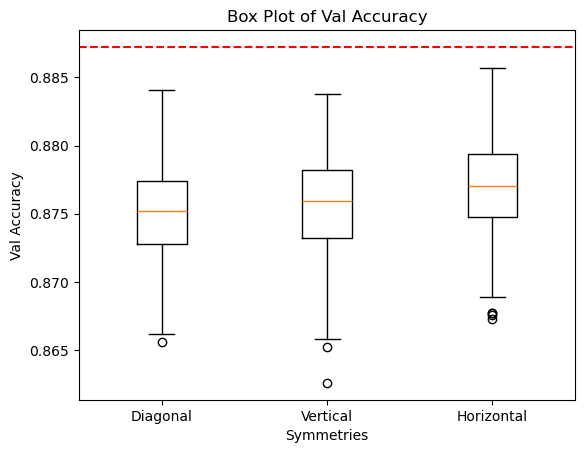

In [14]:
import matplotlib.pyplot as plt

# Combine the data into a list of lists
data = [diagonal_val_accuracy_flattened, vertical_val_accuracy_flattened, horizontal_val_accuracy_flattened]

# Define the labels for the box plot
labels_plot = ['Diagonal', 'Vertical', 'Horizontal']

# Create the box plot
plt.boxplot(data, labels=labels_plot)

# Calculate the mean value of the no_filter list
mean_no_filter = np.mean(no_fitler_val_accuracy)

# Add a horizontal line at the mean value of no_filter
plt.axhline(y= mean_no_filter, color='r', linestyle='--', label=f'Mean No Filter: {mean_no_filter:.2f}')
# plt.ylim(0.936,.97)

# Add title and labels
plt.title('Box Plot of Val Accuracy')
plt.xlabel('Symmetries')
plt.ylabel('Val Accuracy')

# Show the plot
plt.show()